## 🎯 Learning Outcomes

### By the end of this module, you will be able to:

- Understand the **EDA structured loop**: ask a question, explore, visualize, hypothesize, and repeat.
- Perform **Data quality assessment** covering completeness, consistency, accuracy, and timeliness.
- Conduct **Univariate analysis** to characterize center, spread, shape, skewness, and kurtosis.
- Perform **Bivariate / multivariate analysis** to identify correlations and grouped statistics.
- Apply **Outlier detection** techniques like the IQR rule and visual inspection.
- Address **ML-specific concerns** such as class imbalance and target leakage.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

print('pandas    :', pd.__version__)
print('seaborn   :', sns.__version__)

pandas    : 2.2.2
seaborn   : 0.13.2


## Part 1 — Load the Real Titanic Dataset

`sns.load_dataset('titanic')` downloads the classic Titanic passenger manifest directly from the Seaborn data repository. It has **891 rows and 15 columns** and is the same dataset used in virtually every introductory ML course.

| Column | Type | Description |
|---|---|---|
| `survived` | int (0/1) | target — 1 = survived |
| `pclass` | int (1/2/3) | ticket class |
| `sex` | str | `'male'` / `'female'` |
| `age` | float | age in years (20 % missing) |
| `sibsp` | int | siblings + spouses aboard |
| `parch` | int | parents + children aboard |
| `fare` | float | ticket price in £ |
| `embarked` | str | port: `S`=Southampton · `C`=Cherbourg · `Q`=Queenstown |
| `deck` | str | cabin deck (many missing) |
| `who`, `class`, `embark_town`, `alive`, `alone`, `adult_male` | — | derived convenience columns |

In [2]:
# -- Load the real Titanic dataset -----------------------------------------
df = sns.load_dataset('titanic')

print(f'Shape: {df.shape}')
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Part 2 — First Look: shape, types, summaries

In [3]:
print('shape :', df.shape)
print()
df.info()

shape : (891, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [5]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


## Part 3 — Data Quality Assessment

| Dimension | What to check |
|---|---|
| **Completeness** | how many missing values per column? |
| **Consistency** | same units, same date format, same spelling for categories |
| **Accuracy** | plausible ranges (no negative ages, no dates in 2099) |
| **Timeliness** | is the data fresh enough for the question? |

In [6]:
# -- Completeness --------------------------------------------------------------
print("% missing per column:")
print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

% missing per column:
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64


In [7]:
# -- Consistency: spot odd categories ------------------------------------------
for c in ['sex', 'embarked', 'pclass']:
    counts = df[c].value_counts(dropna=False).to_dict()
    print(f"{c:10s} -> {counts}")

sex        -> {'male': 577, 'female': 314}
embarked   -> {'S': 644, 'C': 168, 'Q': 77, nan: 2}
pclass     -> {3: 491, 1: 216, 2: 184}


In [8]:
# -- Accuracy: plausibility checks ---------------------------------------------
print('age in [0, 120] :', df['age'].dropna().between(0, 120).all())
print('fare >= 0       :', (df['fare'] >= 0).all())
print('duplicate rows  :', df.duplicated().sum())

age in [0, 120] : True
fare >= 0       : True
duplicate rows  : 107


## Part 4 — Univariate Analysis

Look at one variable at a time. Characterize **center**, **spread**, and **shape**.

| Statistic | Interpretation |
|---|---|
| mean / median | center; large gap suggests skew or outliers |
| std / IQR | spread; IQR is robust to outliers |
| skewness | asymmetry; > 0 right-tailed, < 0 left-tailed |
| kurtosis | tail weight; > 0 heavier tails (more outliers) than normal |

In [9]:
# -- Numeric: age --------------------------------------------------------------
print(df['age'].describe().round(2))
print(f"\nskewness : {df['age'].skew():.3f}")
print(f"kurtosis : {df['age'].kurt():.3f}")

count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: age, dtype: float64

skewness : 0.389
kurtosis : 0.178


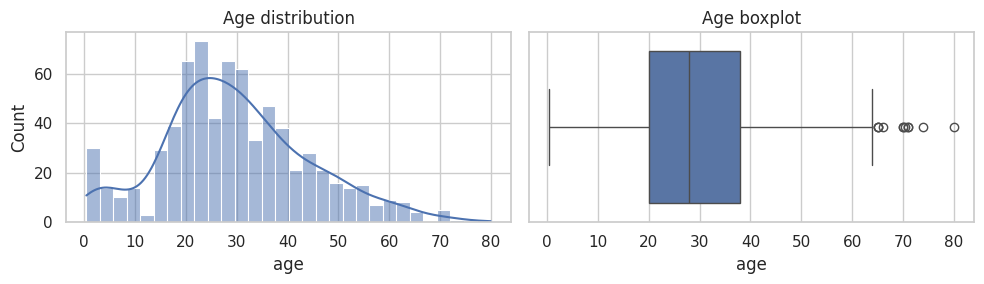

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age distribution')

sns.boxplot(x=df['age'], ax=axes[1])
axes[1].set_title('Age boxplot')

plt.tight_layout(); plt.show()

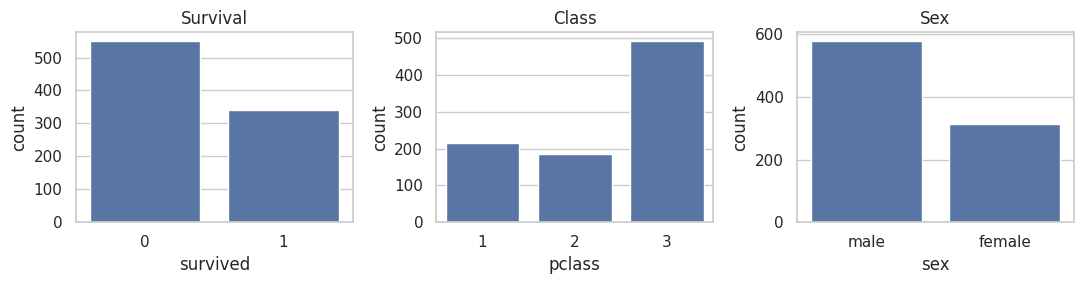

Survival rate: 0.384


In [11]:
# -- Categorical: target balance and other categories --------------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
sns.countplot(data=df, x='survived', ax=axes[0]); axes[0].set_title('Survival')
sns.countplot(data=df, x='pclass',   ax=axes[1]); axes[1].set_title('Class')
sns.countplot(data=df, x='sex',      ax=axes[2]); axes[2].set_title('Sex')
plt.tight_layout(); plt.show()

print(f"Survival rate: {df['survived'].mean():.3f}")

## Part 5 — Bivariate Analysis

Relate each feature to the target.

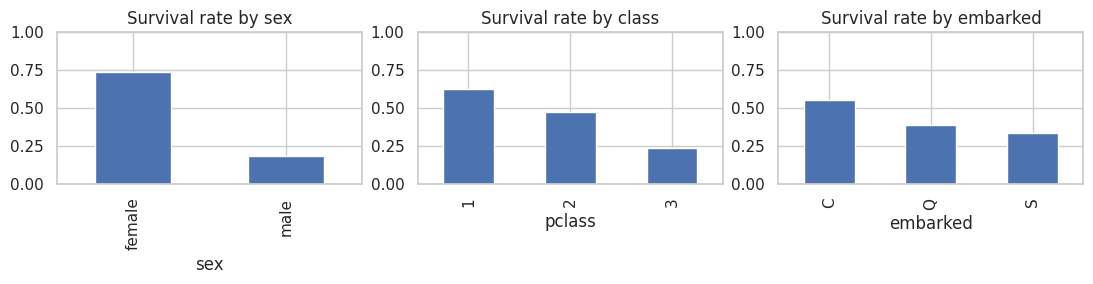

In [12]:
# -- Survival rate by category -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3))

df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Survival rate by sex'); axes[0].set_ylim(0, 1)

df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Survival rate by class'); axes[1].set_ylim(0, 1)

df.groupby('embarked')['survived'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('Survival rate by embarked'); axes[2].set_ylim(0, 1)

plt.tight_layout(); plt.show()

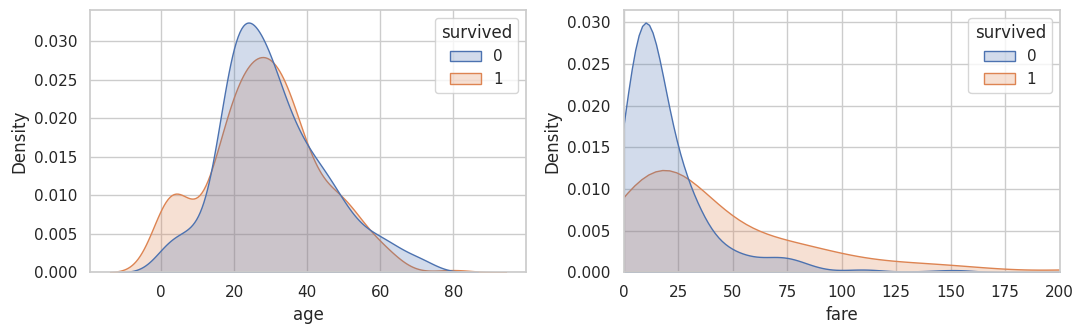

In [13]:
# -- Numeric vs target: distribution of age and fare split by survival ---------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.kdeplot(data=df, x='age',  hue='survived', fill=True, common_norm=False, ax=axes[0])
sns.kdeplot(data=df, x='fare', hue='survived', fill=True, common_norm=False, ax=axes[1])
axes[1].set_xlim(0, 200)
plt.tight_layout(); plt.show()

## Part 6 — Multivariate Analysis

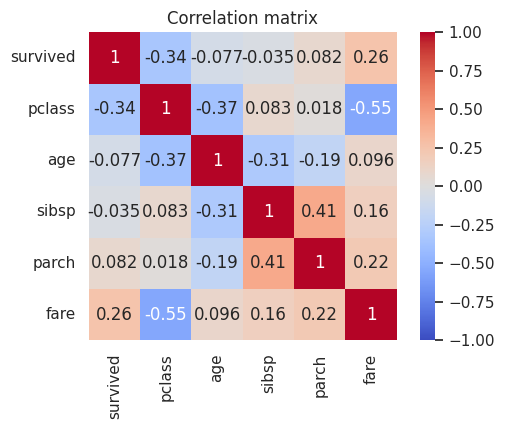

In [14]:
# -- Correlation heatmap on numeric columns ------------------------------------
corr = df.select_dtypes('number').corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation matrix')
plt.show()

In [15]:
# -- Cross-tab: survival by sex AND class --------------------------------------
pd.crosstab([df['sex'], df['pclass']], df['survived'], normalize='index').round(3)

survived           0      1
sex    pclass              
female 1       0.032  0.968
       2       0.079  0.921
       3       0.500  0.500
male   1       0.631  0.369
       2       0.843  0.157
       3       0.865  0.135

## Part 7 — Outlier Detection

The IQR rule: anything below Q1 − 1.5·IQR or above Q3 + 1.5·IQR is flagged.

116 fare outliers (13.0% of rows)
range : 66.60 .. 512.33


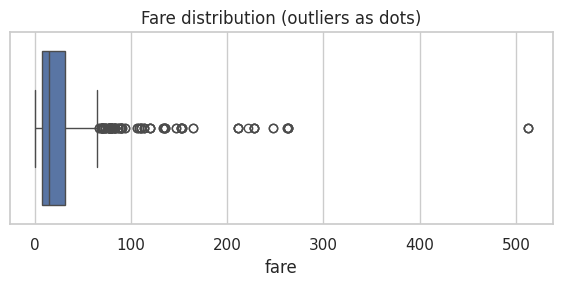

In [16]:
def iqr_outliers(s: pd.Series) -> pd.Series:
    """Return the elements of `s` outside the 1.5*IQR fences."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lo) | (s > hi)]

fare_out = iqr_outliers(df['fare'])
print(f"{len(fare_out)} fare outliers ({len(fare_out)/len(df):.1%} of rows)")
print(f"range : {fare_out.min():.2f} .. {fare_out.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 2.5))
sns.boxplot(x=df['fare'], ax=ax)
ax.set_title('Fare distribution (outliers as dots)')
plt.show()

## Part 8 — ML-Specific Concerns

| Problem | Symptom | Quick check |
|---|---|---|
| **Class imbalance** | minority class < 10% | `df[target].value_counts(normalize=True)` |
| **Target leakage** | one feature is suspiciously predictive | `corr` near ±1 with target, or perfect group means |

In [17]:
# -- Class balance -------------------------------------------------------------
balance = df['survived'].value_counts(normalize=True)
print(balance.round(3))
print(f"\nratio: {balance.max() / balance.min():.2f} : 1")

survived
0    0.616
1    0.384
Name: proportion, dtype: float64

ratio: 1.61 : 1


In [18]:
# -- Target leakage check: any single feature near +/-1 correlation? -----------
df.select_dtypes('number').corr()['survived'].abs().sort_values(ascending=False)

,survived
survived,1.000000
pclass,0.338481
fare,0.257307
parch,0.081629
age,0.077221
sibsp,0.035322


---

## A One-Paragraph EDA Report

> **Observations.** The real Titanic dataset has 891 rows and 15 columns. `age` is missing for ~20 % of passengers, `deck` for ~77 %, and `embarked` for just 2 rows. The overall survival rate is 38 %. Survival is strongly tied to `sex` (women ≈ 74 % vs men ≈ 19 %) and `pclass` (1st ≈ 63 % vs 3rd ≈ 24 %). `fare` is heavily right-skewed with large outliers concentrated in 1st class.
>
> **Hypotheses.** A model using `sex`, `pclass`, and `age` should already perform well. Children (`age < 16`) likely survived at a higher rate (the 'women and children first' protocol).
>
> **Recommendations.** Impute missing `age` with the group median by `(sex, pclass)`. Drop `deck` or use its missingness as a binary feature. Engineer `family_size = sibsp + parch + 1`. Use a stratified train/test split because of the 62/38 class imbalance.

---

## Quick Reference Summary

| Step | Code |
|---|---|
| Shape & types | `df.shape`, `df.info()`, `df.dtypes` |
| % missing per column | `df.isna().mean().sort_values(ascending=False)` |
| Numeric summary | `df.describe()` |
| Class summary | `df.describe(include='object')` |
| Frequencies | `df['col'].value_counts()` |
| Skew / kurtosis | `df['x'].skew()`, `df['x'].kurt()` |
| Survival rate by group | `df.groupby('k')[target].mean()` |
| Correlation heatmap | `sns.heatmap(df.corr(numeric_only=True), annot=True)` |
| IQR outliers | `q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1` |
| Class balance | `df[target].value_counts(normalize=True)` |
| Leakage check | `df.corr()[target].abs().sort_values(ascending=False)` |

---

## Worked Examples

### Example 1 — Stratified imputation of missing age

A common improvement over global-median imputation: fill missing `age` with the median for that passenger's `(sex, pclass)` group.

In [19]:
print("Before imputation:")
print(f"  missing age: {df['age'].isna().sum()}")
print(f"  global median age: {df['age'].median():.1f}")

# -- Group-wise median fill ----------------------------------------------------
df_imp = df.copy()
df_imp['age'] = df_imp.groupby(['sex', 'pclass'])['age'].transform(
    lambda s: s.fillna(s.median())
)

print("\nAfter imputation:")
print(f"  missing age: {df_imp['age'].isna().sum()}")

# -- Show the actual fill values per group -------------------------------------
print("\nGroup medians used to fill:")
print(df.groupby(['sex', 'pclass'])['age'].median().round(1))

Before imputation:
  missing age: 177
  global median age: 28.0

After imputation:
  missing age: 0

Group medians used to fill:
sex     pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: age, dtype: float64


### Example 2 — Engineering a family-size feature

Combine `sibsp` and `parch` into `family_size`, then plot survival rate against it. A textbook example of feature engineering driven by EDA.

In [20]:
df_fe = df_imp.copy()
df_fe['family_size'] = df_fe['sibsp'] + df_fe['parch'] + 1     # +1 = the passenger

# -- Survival rate by family size ----------------------------------------------
rate = df_fe.groupby('family_size')['survived'].agg(['mean', 'count'])
rate

,mean,count
family_size,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


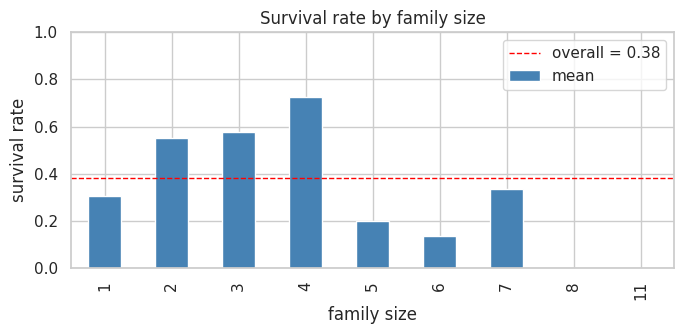

In [21]:
fig, ax = plt.subplots(figsize=(7, 3.5))
rate['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('survival rate')
ax.set_xlabel('family size')
ax.set_title('Survival rate by family size')
ax.set_ylim(0, 1)
ax.axhline(df_fe['survived'].mean(), color='red', linestyle='--',
           linewidth=1, label=f'overall = {df_fe["survived"].mean():.2f}')
ax.legend()
plt.tight_layout(); plt.show()

### Example 3 — Stratified survival analysis

A stacked-bar chart of survival proportions inside each passenger class.

In [22]:
ct = pd.crosstab(df['pclass'], df['survived'], normalize='index')
ct.columns = ['died', 'survived']
ct

,died,survived
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


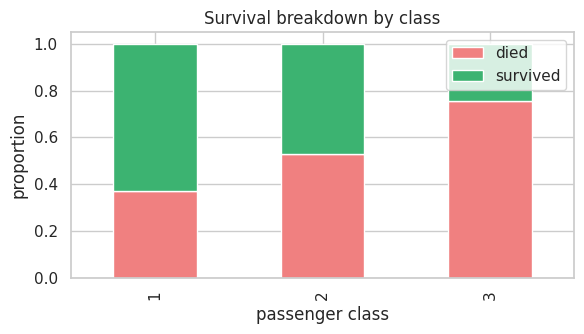

In [23]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ct.plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], ax=ax)
ax.set_ylabel('proportion')
ax.set_xlabel('passenger class')
ax.set_title('Survival breakdown by class')
ax.legend(title=None)
plt.tight_layout(); plt.show()

### Example 4 — Mini end-to-end EDA on a fresh dataset

Apply the same EDA recipe to a synthetic e-commerce dataset: load → quality → univariate → bivariate → recommendations.

In [24]:
rng = np.random.default_rng(42)  # local rng for this example
# -- Synthesize an e-commerce dataset ------------------------------------------
n = 1000
shop = pd.DataFrame({
    'order_id':    range(1, n + 1),
    'customer_age': rng.integers(18, 75, n),
    'category':    rng.choice(['Electronics', 'Clothing', 'Books', 'Home'], n,
                              p=[0.30, 0.40, 0.10, 0.20]),
    'amount':      rng.lognormal(4.0, 0.6, n).round(2),
    'returned':    rng.choice([0, 1], n, p=[0.85, 0.15]),
})

# Inject some missingness
shop.loc[shop.sample(50, random_state=0).index, 'customer_age'] = np.nan
shop.head()

,order_id,customer_age,category,amount,returned
0,1,23.0,Books,97.30,0
1,2,NaN,Home,35.35,0
2,3,55.0,Home,32.71,0
3,4,43.0,Clothing,71.94,0
4,5,42.0,Clothing,98.80,0


In [25]:
# -- Quality + univariate snapshot ---------------------------------------------
print("missing %:")
print((shop.isna().mean() * 100).round(2))
print()
print("amount summary:")
print(shop['amount'].describe().round(2))
print(f"\nreturn rate: {shop['returned'].mean():.3f}")

missing %:
order_id        0.0
customer_age    5.0
category        0.0
amount          0.0
returned        0.0
dtype: float64

amount summary:
count    1000.00
mean       62.35
std        41.84
min         8.69
25%        34.58
50%        53.58
75%        77.54
max       313.73
Name: amount, dtype: float64

return rate: 0.149


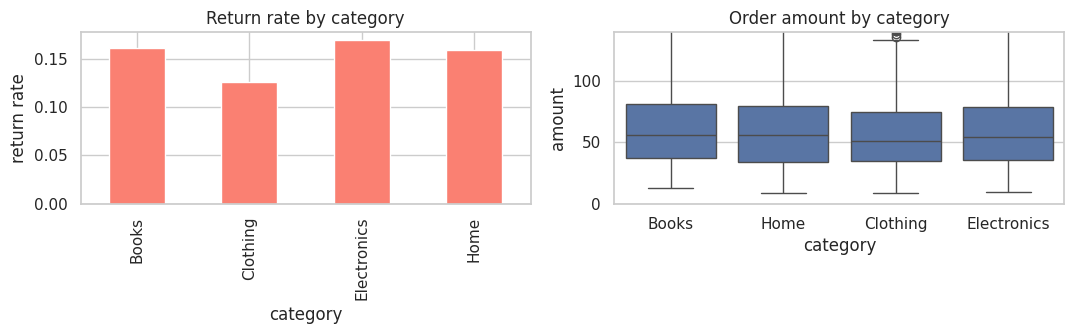

In [26]:
# -- Bivariate: return rate by category ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

shop.groupby('category')['returned'].mean().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Return rate by category')
axes[0].set_ylabel('return rate')

sns.boxplot(data=shop, x='category', y='amount', ax=axes[1])
axes[1].set_title('Order amount by category')
axes[1].set_ylim(0, shop['amount'].quantile(0.95))     # trim long tail

plt.tight_layout(); plt.show()

**Mini-report.** Order amounts are right-skewed (lognormal). Electronics has both the highest average ticket and the highest return rate, while Books has the lowest of both — these probably represent different shopper personas. Recommend tracking return rate as a per-category KPI and investigating whether returns concentrate on specific products within Electronics.

---

## Summary

| Concept | Key Point |
|---------|-----------|
| EDA structured loop | Ask a question, explore, visualize, hypothesize, and repeat. |
| Data quality assessment | Checks for completeness, consistency, accuracy, and timeliness. |
| Univariate analysis | Characterizes center, spread, and shape of a single variable. |
| Bivariate / multivariate analysis | Identifies relationships and correlations between multiple variables. |
| Outlier detection | Techniques like IQR rule and visual inspection to find unusual data points. |
| ML-specific concerns | Addressing issues like class imbalance and target leakage. |
| Missing values | Can be imputed (e.g., with median) or rows dropped. |
| Feature engineering | Creating new features from existing ones (e.g., `family_size`). |
| Visualizations | Using plots (histograms, boxplots, bar plots, heatmaps) to understand data.

### Contributed by: Abdulhadi Zubailah